<a href="https://colab.research.google.com/github/ArjunJayakrishnan-codes/Fitness-Tracker-System-Analysis/blob/main/FitnessTracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                **FITNESS TRACKER SYSTEM ANALYSIS**

PRAYAS KAR [RA2311003010322]

ARJUN JAYAKRISHNAN [RA2311003010326]

TIRTHA NATH [RA2311003010336]

PRIYAM BHARTI [RA2311003010351]







## PART 1: Data Collection

### *PROBLEM STATEMENT*
Design a Fitness Tracking System to analyze fitness activities, monitor workout performance and improve health outcomes using fitness data.

In [4]:
import pandas as pd
df = pd.read_csv("gym_members_exercise_tracking_synthetic_data.csv")
print("Original Dataset:")
display(df.head())

Original Dataset:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83


In [6]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['age', 'gender', 'weight (kg)', 'height (m)', 'max_bpm', 'avg_bpm',
       'resting_bpm', 'session_duration (hours)', 'calories_burned',
       'workout_type', 'fat_percentage', 'water_intake (liters)',
       'workout_frequency (days/week)', 'experience_level', 'bmi'],
      dtype='object')


Create 3 Tables

Body Metrics Table

In [7]:
body = df[['age', 'gender', 'weight (kg)', 'height (m)', 'bmi']]

display(body.head())
body.info()

,age,gender,weight (kg),height (m),bmi
0,34.0,Female,86.7,1.86,14.31
1,26.0,Female,84.7,1.83,33.49
2,22.0,Male,64.8,1.85,12.73
3,54.0,Female,75.3,1.82,20.37
4,34.0,Female,52.8,1.74,20.83


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1790 non-null   float64
 1   gender       1729 non-null   object 
 2   weight (kg)  1778 non-null   float64
 3   height (m)   1774 non-null   float64
 4   bmi          1770 non-null   float64
dtypes: float64(4), object(1)
memory usage: 70.4+ KB


Workout Table

In [8]:
workout = df[['workout_type', 'session_duration (hours)', 'calories_burned',
              'workout_frequency (days/week)', 'experience_level']]

display(workout.head())
workout.info()

,workout_type,session_duration (hours),calories_burned,workout_frequency (days/week),experience_level
0,Strength,1.12,712.0,5.0,2.0
1,Strength,1.00,833.0,5.0,2.0
2,Cardio,1.24,1678.0,3.0,2.0
3,Cardio,1.45,628.0,4.0,1.0
4,Strength,1.60,1286.0,4.0,2.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   workout_type                   1739 non-null   object 
 1   session_duration (hours)       1777 non-null   float64
 2   calories_burned                1777 non-null   float64
 3   workout_frequency (days/week)  1742 non-null   float64
 4   experience_level               1743 non-null   float64
dtypes: float64(4), object(1)
memory usage: 70.4+ KB


Health Metrics

In [9]:
health = df[['max_bpm', 'avg_bpm', 'resting_bpm',
             'fat_percentage', 'water_intake (liters)']]

display(health.head())
health.info()

,max_bpm,avg_bpm,resting_bpm,fat_percentage,water_intake (liters)
0,174,152.0,74.0,12.8,2.4
1,166,156.0,73.0,27.9,2.8
2,187,166.0,64.0,28.7,1.9
3,187,169.0,58.0,31.8,2.4
4,177,169.0,66.0,26.4,3.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   max_bpm                1779 non-null   object 
 1   avg_bpm                1770 non-null   float64
 2   resting_bpm            1781 non-null   float64
 3   fat_percentage         1784 non-null   float64
 4   water_intake (liters)  1776 non-null   float64
dtypes: float64(4), object(1)
memory usage: 70.4+ KB


In [11]:
body.to_csv("members.csv", index=False)
workout.to_csv("workout.csv", index=False)
health.to_csv("health.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


## PART 2: Data Wrangling & Cleaning

1. Handling Missing Values

In [ ]:
# BEFORE
print("Missing Values BEFORE:")
print(df.isnull().sum())

# Apply mean imputation
df.fillna(df.mean(numeric_only=True), inplace=True)

# AFTER
print("\nMissing Values AFTER:")
print(df.isnull().sum())
print("Missing values can affect analysis accuracy, so we fill numeric columns with mean")

Missing Values BEFORE:
age                               0
gender                           71
weight (kg)                       0
height (m)                        0
max_bpm                          21
avg_bpm                           0
resting_bpm                       0
session_duration (hours)          0
calories_burned                   0
workout_type                     61
fat_percentage                    0
water_intake (liters)             0
workout_frequency (days/week)     0
experience_level                  0
bmi                               0
dtype: int64

Missing Values AFTER:
age                               0
gender                           71
weight (kg)                       0
height (m)                        0
max_bpm                          21
avg_bpm                           0
resting_bpm                       0
session_duration (hours)          0
calories_burned                   0
workout_type                     61
fat_percentage                    0
water

2. Removing Duplicates

In [ ]:
# BEFORE
print("Duplicate Rows BEFORE:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# AFTER
print("Duplicate Rows AFTER:", df.duplicated().sum())
print("Duplicate records can bias results and lead to incorrect analysis")

Duplicate Rows BEFORE: 0
Duplicate Rows AFTER: 0
Duplicate records can bias results and lead to incorrect analysis


3. Data Type Conversion

In [ ]:
# BEFORE
print("\nData Types BEFORE:")
print(df.dtypes)

# Example: ensure calories_burned is numeric
df['calories_burned'] = pd.to_numeric(df['calories_burned'], errors='coerce')

# AFTER
print("\nData Types AFTER:")
print(df.dtypes)
print("Ensure correct numeric format for calculations")


Data Types BEFORE:
age                              float64
gender                            object
weight (kg)                      float64
height (m)                       float64
max_bpm                           object
avg_bpm                          float64
resting_bpm                      float64
session_duration (hours)         float64
calories_burned                  float64
workout_type                      object
fat_percentage                   float64
water_intake (liters)            float64
workout_frequency (days/week)    float64
experience_level                 float64
bmi                              float64
dtype: object

Data Types AFTER:
age                              float64
gender                            object
weight (kg)                      float64
height (m)                       float64
max_bpm                           object
avg_bpm                          float64
resting_bpm                      float64
session_duration (hours)         float64
calo

4. String Cleaning (Formatting)

In [ ]:
# BEFORE
print("\nGender BEFORE:", df['gender'].unique())

df['gender'] = df['gender'].str.strip().str.lower()

# AFTER
print("Gender AFTER:", df['gender'].unique())
print("Standardizing text avoids inconsistency (e.g., Male, male, MALE)")


Gender BEFORE: ['Female' 'Male' nan]
Gender AFTER: ['female' 'male' nan]
Standardizing text avoids inconsistency (e.g., Male, male, MALE)


5. Filtering and Sorting

In [ ]:
# BEFORE
print("\nOriginal Data:")
display(df.head())

filtered_df = df[df['calories_burned'] > df['calories_burned'].mean()]
sorted_df = filtered_df.sort_values(by='calories_burned', ascending=False)

# AFTER
print("\nFiltered & Sorted Data:")
display(sorted_df.head())
print("Filtering helps focus on high-performing workouts")


Original Data:


,age,gender,weight (kg),height (m),max_bpm,avg_bpm,resting_bpm,session_duration (hours),calories_burned,workout_type,fat_percentage,water_intake (liters),workout_frequency (days/week),experience_level,bmi,calories_z
0,34.0,female,86.7,1.86,174,152.0,74.0,1.12,712.0,strength,12.8,2.4,5.0,2.0,14.31,-0.987245
1,26.0,female,84.7,1.83,166,156.0,73.0,1.00,833.0,strength,27.9,2.8,5.0,2.0,33.49,-0.615914
2,22.0,male,64.8,1.85,187,166.0,64.0,1.24,1678.0,cardio,28.7,1.9,3.0,2.0,12.73,1.977261
3,54.0,female,75.3,1.82,187,169.0,58.0,1.45,628.0,cardio,31.8,2.4,4.0,1.0,20.37,-1.245028
4,34.0,female,52.8,1.74,177,169.0,66.0,1.60,1286.0,strength,26.4,3.2,4.0,2.0,20.83,0.774273



Filtered & Sorted Data:


,age,gender,weight (kg),height (m),max_bpm,avg_bpm,resting_bpm,session_duration (hours),calories_burned,workout_type,fat_percentage,water_intake (liters),workout_frequency (days/week),experience_level,bmi,calories_z
1693,18.0,male,87.3,1.710000,199,145.0,65.0,1.16,1783.0,cardio,30.0,3.3,3.000000,3.0,12.32,2.29949
893,44.0,male,52.5,1.650000,174,169.0,51.0,1.95,1783.0,cardio,29.4,2.0,2.000000,1.0,16.41,2.29949
925,25.0,female,102.8,2.000000,166,131.0,73.0,1.28,1783.0,cardio,27.1,3.2,3.339265,1.0,14.05,2.29949
134,38.0,female,59.0,1.739233,169,134.0,67.0,1.36,1783.0,yoga,24.5,2.4,3.000000,1.0,12.32,2.29949
144,33.0,female,97.1,1.860000,166,127.0,72.0,1.39,1783.0,hiit,11.0,1.5,4.000000,1.0,16.27,2.29949


Filtering helps focus on high-performing workouts


## PART 3: Data Preparation & Analysis

1. Data Summarization

Statistical Measures (Mean, Median)

In [ ]:
print("Mean Values:\n", df.mean(numeric_only=True))
print("\nMedian Values:\n", df.median(numeric_only=True))

Mean Values:
 age                                34.475419
weight (kg)                        67.606637
height (m)                          1.739233
avg_bpm                           146.259322
resting_bpm                        63.951151
session_duration (hours)            1.391598
calories_burned                  1033.698931
fat_percentage                     23.509361
water_intake (liters)               2.706644
workout_frequency (days/week)       3.339265
experience_level                    1.823867
bmi                                19.957774
dtype: float64

Median Values:
 age                                33.000000
weight (kg)                        65.700000
height (m)                          1.739233
avg_bpm                           146.000000
resting_bpm                        65.000000
session_duration (hours)            1.370000
calories_burned                  1033.698931
fat_percentage                     24.200000
water_intake (liters)               2.706644
workout_f

Dataset Summary

In [ ]:
df.describe()

,age,weight (kg),height (m),avg_bpm,resting_bpm,session_duration (hours),calories_burned,fat_percentage,water_intake (liters),workout_frequency (days/week),experience_level,bmi
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,34.475419,67.606637,1.739233,146.259322,63.951151,1.391598,1033.698931,23.509361,2.706644,3.339265,1.823867,19.957774
std,12.281451,19.739592,0.122993,15.092083,7.894480,0.369954,325.945879,5.839416,0.705470,0.932548,0.734645,6.518137
min,18.000000,40.000000,1.500000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,23.750000,52.575000,1.660000,134.000000,57.000000,1.140000,800.000000,20.500000,2.100000,3.000000,1.000000,14.860000
50%,33.000000,65.700000,1.739233,146.000000,65.000000,1.370000,1033.698931,24.200000,2.706644,3.000000,2.000000,18.850000
75%,45.000000,80.000000,1.820000,159.000000,72.000000,1.630000,1246.250000,27.500000,3.300000,4.000000,2.000000,23.322500
max,59.000000,129.900000,2.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


Group-Based Analysis

In [ ]:
group_exp = df.groupby('experience_level')['calories_burned'].mean()

print("Average Calories Burned by Experience Level:")
print(group_exp)

Average Calories Burned by Experience Level:
experience_level
1.000000    1033.652540
1.823867     954.456140
2.000000    1039.263081
3.000000    1035.238416
Name: calories_burned, dtype: float64


2. Standardization


Apply Z-score Scaling

In [ ]:
from scipy.stats import zscore

# BEFORE
print("Before Scaling:")
display(df['calories_burned'].head())

# Apply scaling
df['calories_z'] = zscore(df['calories_burned'])

# AFTER
print("\nAfter Scaling:")
display(df[['calories_burned', 'calories_z']].head())

Before Scaling:


,calories_burned
0,712.0
1,833.0
2,1678.0
3,628.0
4,1286.0



After Scaling:


,calories_burned,calories_z
0,712.0,-0.987245
1,833.0,-0.615914
2,1678.0,1.977261
3,628.0,-1.245028
4,1286.0,0.774273


3. Outlier Detection & Removal


Detect using IQR or Z-score

In [ ]:
# BEFORE
print("Dataset Shape BEFORE:", df.shape)

Q1 = df['calories_burned'].quantile(0.25)
Q3 = df['calories_burned'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Dataset Shape BEFORE: (1800, 16)
Lower Bound: 130.625
Upper Bound: 1915.625


In [ ]:
df_clean = df[(df['calories_burned'] >= lower_bound) &
              (df['calories_burned'] <= upper_bound)]

# AFTER
print("\nDataset Shape AFTER:", df_clean.shape)


Dataset Shape AFTER: (1800, 16)


In [ ]:
print("Before Outlier Removal:\n", df['calories_burned'].describe())
print("\nAfter Outlier Removal:\n", df_clean['calories_burned'].describe())

Before Outlier Removal:
 count    1800.000000
mean     1033.698931
std       325.945879
min       303.000000
25%       800.000000
50%      1033.698931
75%      1246.250000
max      1783.000000
Name: calories_burned, dtype: float64

After Outlier Removal:
 count    1800.000000
mean     1033.698931
std       325.945879
min       303.000000
25%       800.000000
50%      1033.698931
75%      1246.250000
max      1783.000000
Name: calories_burned, dtype: float64


## PART 4: Visualization using Matplotlib

In [ ]:
import matplotlib.pyplot as plt

1. Line Plot

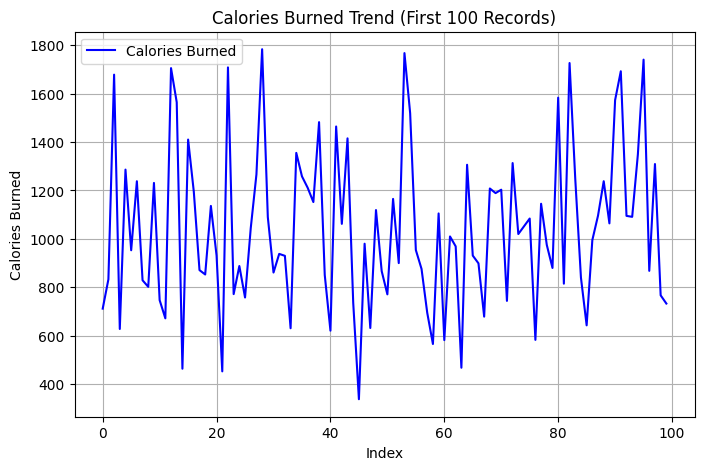

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(df['calories_burned'].head(100), label='Calories Burned', color='blue')

plt.title("Calories Burned Trend (First 100 Records)")
plt.xlabel("Index")
plt.ylabel("Calories Burned")
plt.legend()
plt.grid(True)

plt.show()

2. Bar Plot

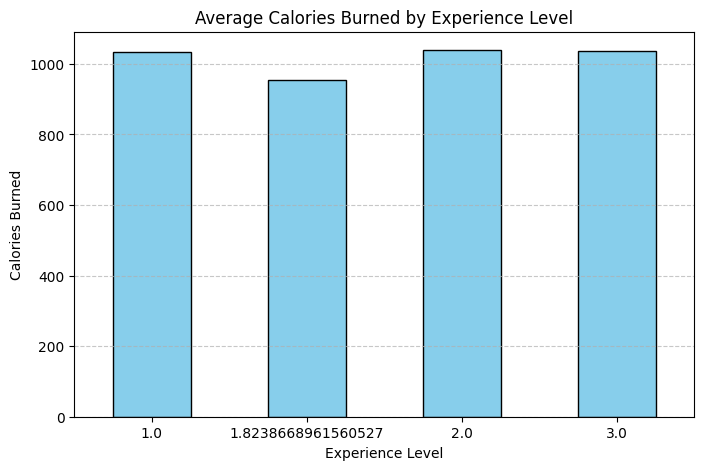

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.groupby('experience_level')['calories_burned'].mean().plot(
    kind='bar', color='skyblue', edgecolor='black'
)

plt.title("Average Calories Burned by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Calories Burned")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

3. Scatter Plot

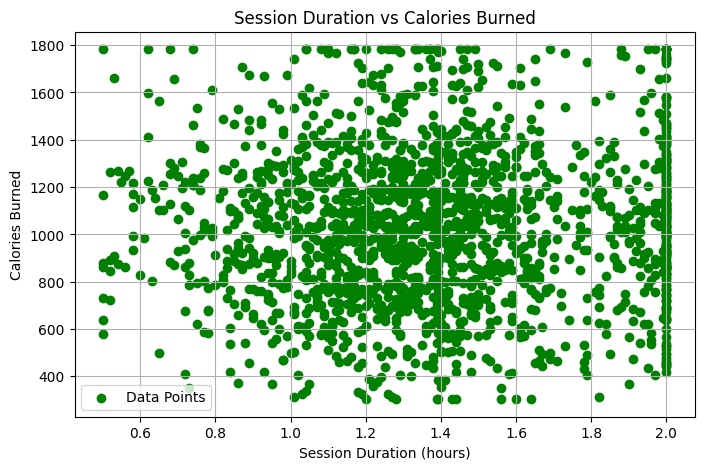

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['session_duration (hours)'],
    df['calories_burned'],
    color='green',
    label='Data Points'
)

plt.title("Session Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.legend()
plt.grid(True)

plt.show()

## PART 5: Visualization using Seaborn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Better styling
sns.set(style="whitegrid")

1. Heatmap

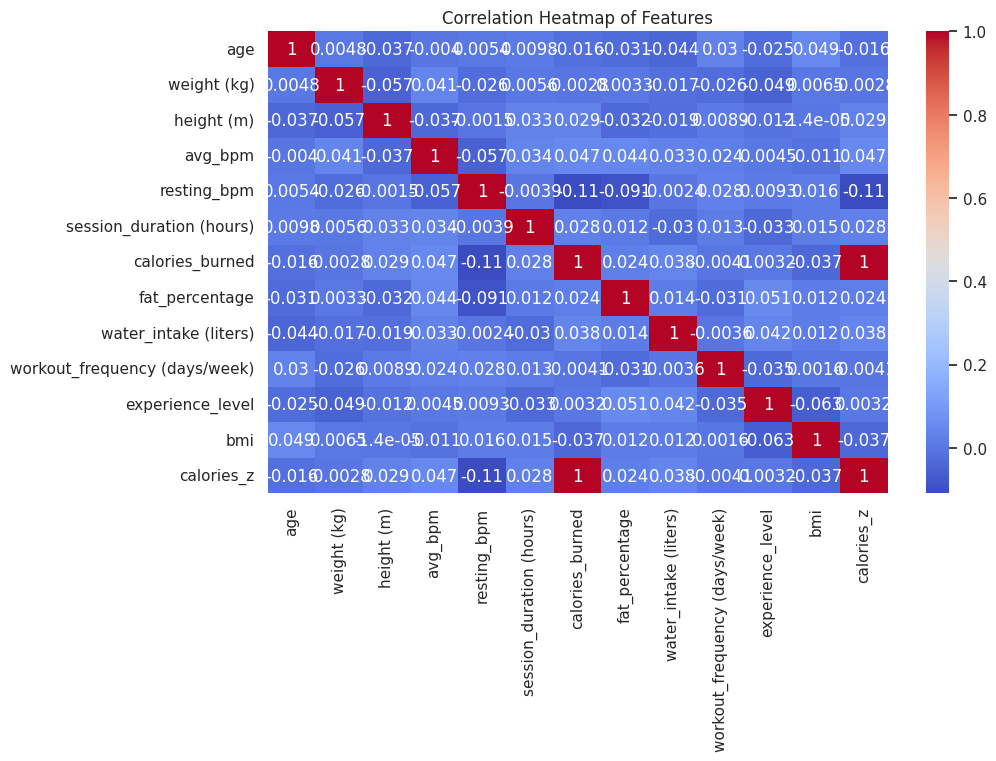

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Features")
plt.show()

2. Pairplot

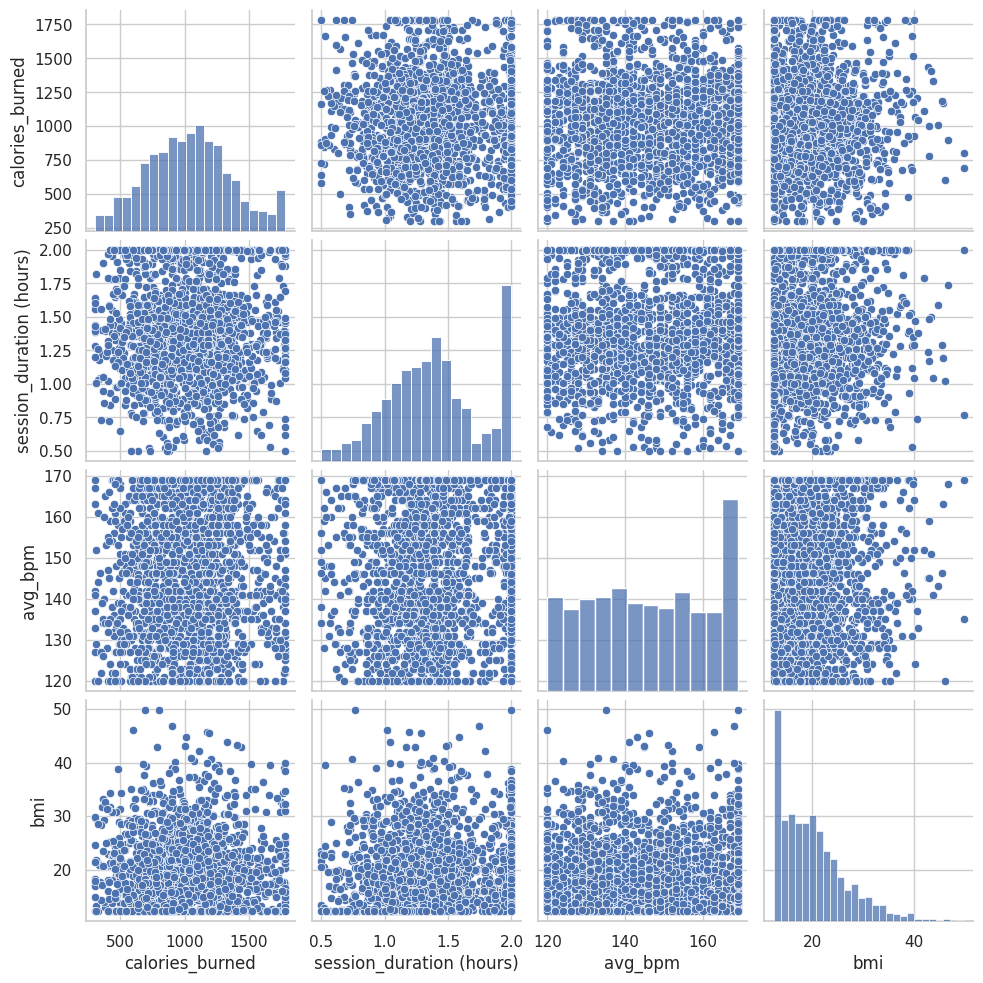

In [ ]:
sns.pairplot(df[['calories_burned', 'session_duration (hours)', 'avg_bpm', 'bmi']])
plt.show()

3. Countplot

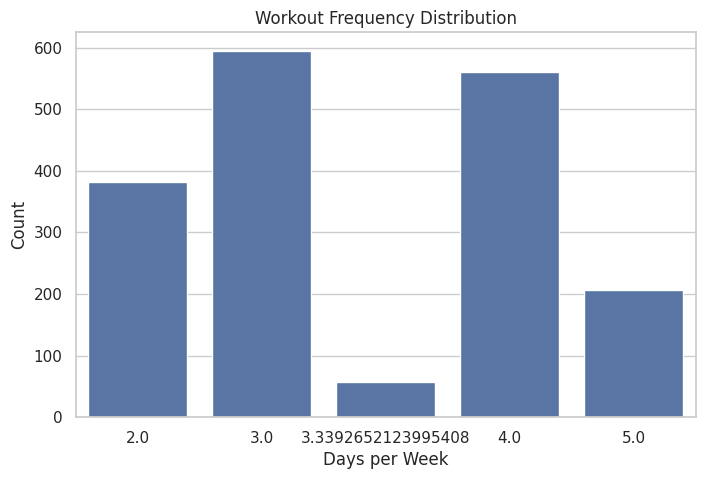

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='workout_frequency (days/week)', data=df)

plt.title("Workout Frequency Distribution")
plt.xlabel("Days per Week")
plt.ylabel("Count")

plt.show()

4. Boxplot

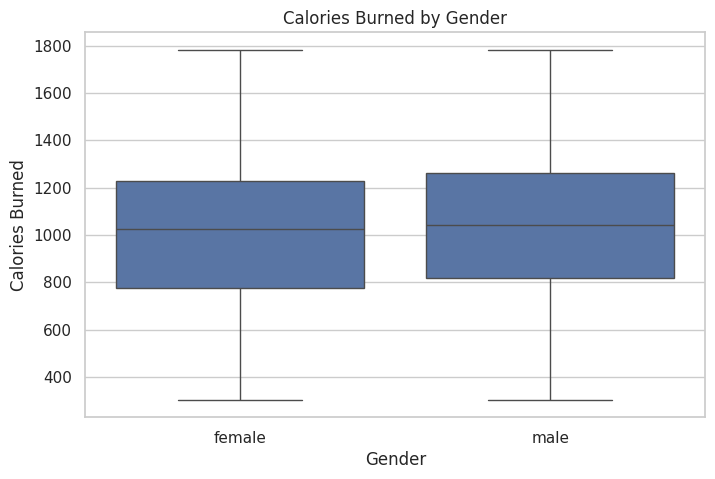

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='gender', y='calories_burned', data=df)

plt.title("Calories Burned by Gender")
plt.xlabel("Gender")
plt.ylabel("Calories Burned")

plt.show()

5. Violin Plot

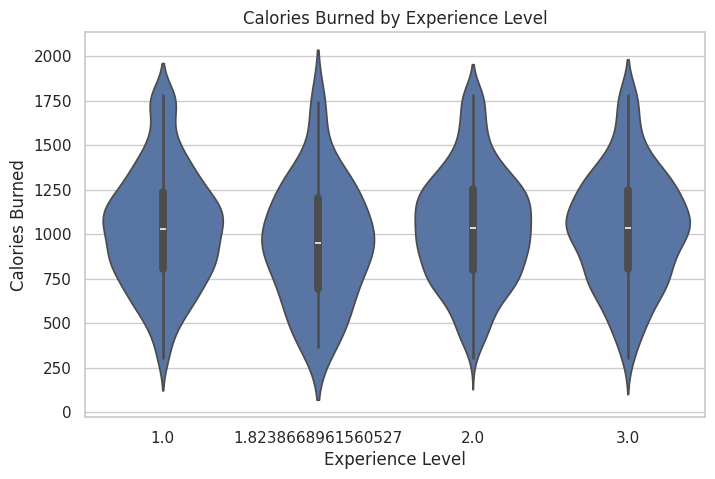

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(x='experience_level', y='calories_burned', data=df)

plt.title("Calories Burned by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Calories Burned")

plt.show()

## PART 6: Insights & Conclusion



###  Key Findings
1. Workout duration increases calories burned  
2. Experienced users burn more calories  
3. Higher heart rate → higher intensity  

###  Observations
- Moderate calorie distribution  
- Frequency affects performance  

### Future Scope
- Real-time tracking  
- ML-based predictions  
- Personalized plans  

###  Conclusion
Workout duration, intensity, and experience significantly impact fitness outcomes.